Setting up device and model...
Using device: cuda


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:02<00:00, 225MB/s]



Loading datasets...
Found 485 images in /kaggle/input/lol-dataset/lol_dataset/our485
Found 15 images in /kaggle/input/lol-dataset/lol_dataset/eval15

Starting training...
Epoch 1/100 | Loss: 0.2639 | Time: 57.18s
Epoch 2/100 | Loss: 0.2483 | Time: 62.29s
Epoch 3/100 | Loss: 0.2268 | Time: 66.99s
Epoch 4/100 | Loss: 0.2052 | Time: 66.96s
Epoch 5/100 | Loss: 0.1915 | Time: 67.00s
Epoch 6/100 | Loss: 0.1866 | Time: 66.99s
Epoch 7/100 | Loss: 0.1829 | Time: 66.66s
Epoch 8/100 | Loss: 0.1832 | Time: 66.54s
Epoch 9/100 | Loss: 0.1787 | Time: 66.57s
Epoch 10/100 | Loss: 0.1800 | Time: 66.53s
Epoch 11/100 | Loss: 0.1767 | Time: 66.83s
Epoch 12/100 | Loss: 0.1757 | Time: 67.27s
Epoch 13/100 | Loss: 0.1747 | Time: 66.57s
Epoch 14/100 | Loss: 0.1714 | Time: 67.10s
Epoch 15/100 | Loss: 0.1740 | Time: 67.26s
Epoch 16/100 | Loss: 0.1717 | Time: 67.22s
Epoch 17/100 | Loss: 0.1709 | Time: 66.84s
Epoch 18/100 | Loss: 0.1677 | Time: 66.72s
Epoch 19/100 | Loss: 0.1679 | Time: 67.32s
Epoch 20/100 | Loss:

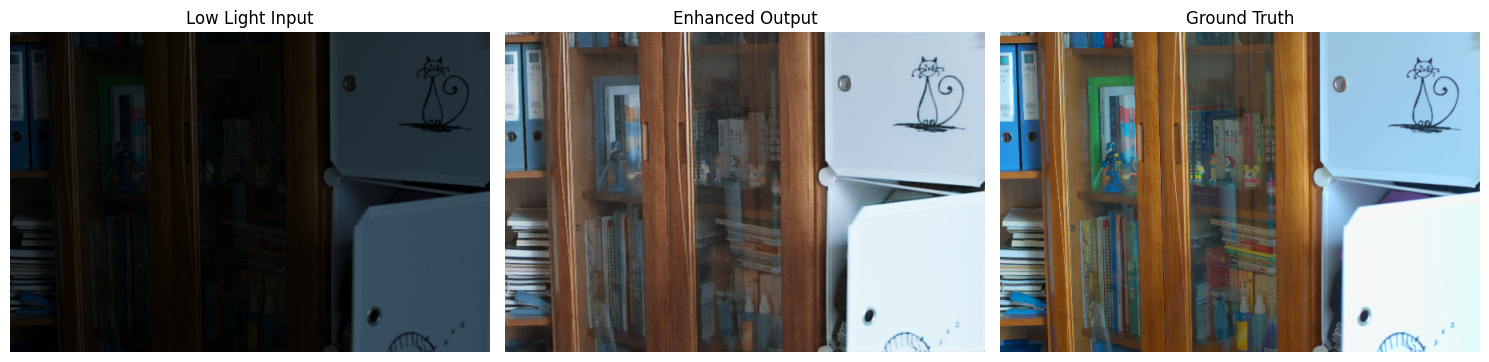


Training complete!


In [1]:
# ================== IMPORTS ==================
import os, cv2, torch, numpy as np, time
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg19, VGG19_Weights
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

# ================== DATASET ==================
class LOLDataset(Dataset):
    def __init__(self, root):
        self.low_dir = os.path.join(root, "low")
        self.high_dir = os.path.join(root, "high")
        
        # Check if directories exist
        if not os.path.exists(self.low_dir):
            raise FileNotFoundError(f"Low light directory not found: {self.low_dir}")
        if not os.path.exists(self.high_dir):
            raise FileNotFoundError(f"High light directory not found: {self.high_dir}")
        
        self.files = sorted(os.listdir(self.low_dir))
        print(f"Found {len(self.files)} images in {root}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        low_path = os.path.join(self.low_dir, self.files[idx])
        high_path = os.path.join(self.high_dir, self.files[idx])
        
        low = cv2.imread(low_path)
        high = cv2.imread(high_path)
        
        if low is None or high is None:
            raise ValueError(f"Failed to load images: {self.files[idx]}")

        low = cv2.cvtColor(low, cv2.COLOR_BGR2RGB) / 255.0
        high = cv2.cvtColor(high, cv2.COLOR_BGR2RGB) / 255.0

        low = torch.from_numpy(low).permute(2,0,1).float()
        high = torch.from_numpy(high).permute(2,0,1).float()
        return low, high

# ================== CBAM ATTENTION ==================
class CBAM(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(ch, ch//8, 1),
            nn.ReLU(),
            nn.Conv2d(ch//8, ch, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.fc(self.avg(x))

# ================== CONV BLOCK ==================
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            CBAM(out_c),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)

# ================== RETINEX U-NET ==================
class RetinexUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = ConvBlock(3, 32)
        self.e2 = ConvBlock(32, 64)
        self.e3 = ConvBlock(64, 128)

        self.d2 = ConvBlock(128+64, 64)
        self.d1 = ConvBlock(64+32, 32)

        self.out = nn.Conv2d(32, 3, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(F.avg_pool2d(e1, 2))
        e3 = self.e3(F.avg_pool2d(e2, 2))

        d2 = self.d2(torch.cat([F.interpolate(e3, scale_factor=2, mode='bilinear', align_corners=False), e2], 1))
        d1 = self.d1(torch.cat([F.interpolate(d2, scale_factor=2, mode='bilinear', align_corners=False), e1], 1))

        return torch.sigmoid(self.out(d1))

# ================== FINAL MODEL ==================
class LAPFormerNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = RetinexUNet()

    def forward(self, x):
        return torch.clamp(self.net(x), 0, 1)

# ================== LOSSES ==================
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features[:16]
        self.vgg = vgg.eval()
        for p in self.vgg.parameters():
            p.requires_grad = False

    def forward(self, x, y):
        return F.l1_loss(self.vgg(x), self.vgg(y))

def color_loss(x, y):
    return F.l1_loss(x.mean([2,3]), y.mean([2,3]))

# ================== SETUP ==================
print("Setting up device and model...")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = LAPFormerNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
percep = PerceptualLoss().to(device)

# Kaggle paths
train_path = "/kaggle/input/lol-dataset/lol_dataset/our485"
test_path = "/kaggle/input/lol-dataset/lol_dataset/eval15"

print("\nLoading datasets...")
train_ds = LOLDataset(train_path)
test_ds = LOLDataset(test_path)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)

# ================== TRAIN ==================
print("\nStarting training...")
epochs = 100
best_loss = float('inf')

for epoch in range(epochs):
    model.train()
    total_loss = 0
    start_time = time.time()

    for batch_idx, (low, high) in enumerate(train_loader):
        low, high = low.to(device), high.to(device)
        pred = model(low)

        loss = (
            F.l1_loss(pred, high) +
            0.1 * percep(pred, high) +
            0.05 * color_loss(pred, high)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    epoch_time = time.time() - start_time
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Time: {epoch_time:.2f}s")
    
    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "best_model.pth")

# ================== SAVE FINAL MODEL ==================
torch.save(model.state_dict(), "LAPFormerNet_final.pth")
print("\nModel saved.")

# ================== EVALUATION ==================
print("\nEvaluating on test set...")
model.eval()
psnr_list, ssim_list = [], []

with torch.no_grad():
    for idx in range(len(test_ds)):
        low, high = test_ds[idx]
        pred = model(low.unsqueeze(0).to(device))[0].cpu().numpy()
        high_np = high.numpy()
        
        # Convert from CHW to HWC for metric calculation
        pred = np.transpose(pred, (1, 2, 0))
        high_np = np.transpose(high_np, (1, 2, 0))
        
        psnr_val = psnr(high_np, pred, data_range=1.0)
        ssim_val = ssim(high_np, pred, channel_axis=2, data_range=1.0)
        
        psnr_list.append(psnr_val)
        ssim_list.append(ssim_val)

print(f"\nAverage PSNR: {np.mean(psnr_list):.4f}")
print(f"Average SSIM: {np.mean(ssim_list):.4f}")

# ================== VISUAL COMPARISON ==================
print("\nGenerating visual comparison...")
model.eval()
with torch.no_grad():
    low, high = test_ds[0]
    pred = model(low.unsqueeze(0).to(device))[0].cpu()

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(low.permute(1, 2, 0))
plt.title("Low Light Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred.permute(1, 2, 0))
plt.title("Enhanced Output")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(high.permute(1, 2, 0))
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.savefig("comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTraining complete!")